## Results

In [7]:
from pathlib import Path


DATASET_LIST = [
    'BPIC_13_C',
    'BPIC_13_I',
    'BPIC_20_DD',
    'BPIC_20_ID',
    'BPIC_20_PTC',
    'BPIC_20_RFP',
    'BPIC_20_TPD',
    'Helpdesk',
]

DATASET_FOLDER = Path('C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/')

In [8]:
BASE_FOLDER = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/next_activity/baseline/'
)

BASE_FILENAME = 'results.csv'

PREDICTIONS_DICT = {
    'BPIC_13_C': {
        'darwin': 'bpic_13_c_darwin_classifier_211d8663_2026-04-15_22-52-27',
        'darwin_transformer': 'bpic_13_c_darwin_classifier_51377bf1_2026-04-29_16-51-05',
        'aht': 'bpic_13_c_aht_c1652eae_2026-04-15_22-44-19',
        'arf': 'bpic_13_c_arf_ac2b77f3_2026-04-15_22-45-26',
        'srp': 'bpic_13_c_srp_f890cc58_2026-04-15_23-04-22',
    },
    'BPIC_13_I': {
        'darwin': 'bpic_13_i_darwin_classifier_f5457a3f_2026-04-15_22-52-51',
        'darwin_transformer': 'bpic_13_i_darwin_classifier_6c6e5408_2026-04-30_00-30-12',
        'aht': 'bpic_13_i_aht_9b6579da_2026-04-15_22-44-19',
        'arf': 'bpic_13_i_arf_e709e107_2026-04-15_22-45-34',
        'srp': 'bpic_13_i_srp_31aecc01_2026-04-15_23-07-51',
    },
    'BPIC_20_DD': {
        'darwin': 'bpic_20_dd_darwin_classifier_3c0299d4_2026-04-18_17-21-20',
        'darwin_transformer': 'bpic_20_dd_darwin_classifier_36aca386_2026-04-28_18-39-59',
        'aht': 'bpic_20_dd_aht_c24b3254_2026-04-15_22-44-19',
        'arf': 'bpic_20_dd_arf_c23a081c_2026-04-15_22-45-48',
        'srp': 'bpic_20_dd_srp_bf20df3d_2026-04-15_23-09-29',
    },
    'BPIC_20_ID': {
        'darwin': 'bpic_20_id_darwin_classifier_6024f58a_2026-04-28_13-03-14',
        'darwin_transformer': 'bpic_20_id_darwin_classifier_e99bc42b_2026-04-28_12-52-22',
        'aht': 'bpic_20_id_aht_6fe17736_2026-04-15_22-44-19',
        'arf': 'bpic_20_id_arf_f314de13_2026-04-15_22-47-48',
        'srp': 'bpic_20_id_srp_8d4dfdea_2026-04-15_23-14-49',
    },
    'BPIC_20_PTC': {
        'darwin': 'bpic_20_ptc_darwin_classifier_729cf2bb_2026-04-16_10-09-48',
        'darwin_transformer': 'bpic_20_ptc_darwin_classifier_859c797d_2026-04-28_10-39-39',
        'aht': 'bpic_20_ptc_aht_4662ecef_2026-04-15_22-44-27',
        'arf': 'bpic_20_ptc_arf_e4bebb94_2026-04-15_22-48-10',
        'srp': 'bpic_20_ptc_srp_772e4d4b_2026-04-15_23-17-16',
    },
    'BPIC_20_RFP': {
        'darwin': 'bpic_20_rfp_darwin_classifier_4b46d157_2026-04-27_22-06-28',
        'darwin_transformer': 'bpic_20_rfp_darwin_classifier_5691b6da_2026-04-28_10-21-18',
        'aht': 'bpic_20_rfp_aht_a4ff834c_2026-04-15_22-45-08',
        'arf': 'bpic_20_rfp_arf_976c404e_2026-04-15_22-49-37',
        'srp': 'bpic_20_rfp_srp_6d6af37b_2026-04-15_23-37-07',
    },
    'BPIC_20_TPD': {
        'darwin': 'bpic_20_tpd_darwin_classifier_57466802_2026-04-15_23-00-40',
        'darwin_transformer': 'bpic_20_tpd_darwin_classifier_182743d0_2026-04-28_09-54-05',
        'aht': 'bpic_20_tpd_aht_0a206627_2026-04-15_22-45-12',
        'arf': 'bpic_20_tpd_arf_5d26b40a_2026-04-15_22-51-11',
        'srp': 'bpic_20_tpd_srp_a96ff756_2026-04-16_07-56-14',
    },
    'Helpdesk': {
        'darwin': 'helpdesk_darwin_classifier_4f4d8b54_2026-04-16_10-37-11',
        'darwin_transformer': 'helpdesk_darwin_classifier_f7a51414_2026-04-28_09-55-34',
        'aht': 'helpdesk_aht_dcef8f1c_2026-04-15_22-45-13',
        'arf': 'helpdesk_arf_860e352f_2026-04-15_22-51-57',
        'srp': 'helpdesk_srp_35e698c6_2026-04-16_00-06-03',
    },
}

## Performance plots (archive)

### F-score vs Prefix Length

How good is the model at predicting target when only a few events have been observed?

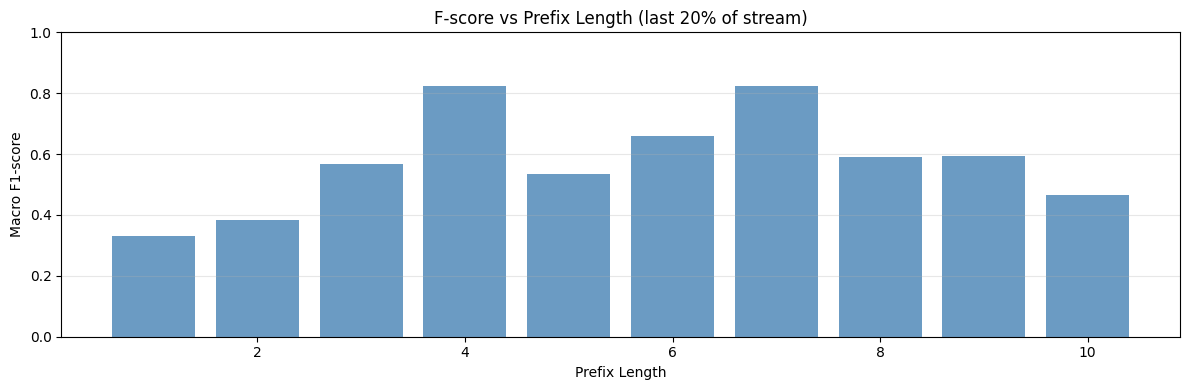

### F-score vs Stream Progress

Is the model performance changing over time? Display drift points

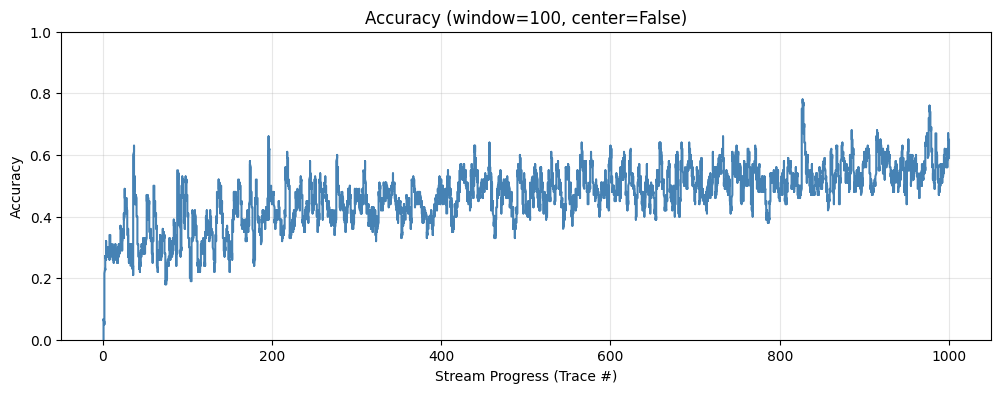

### Prediction Density

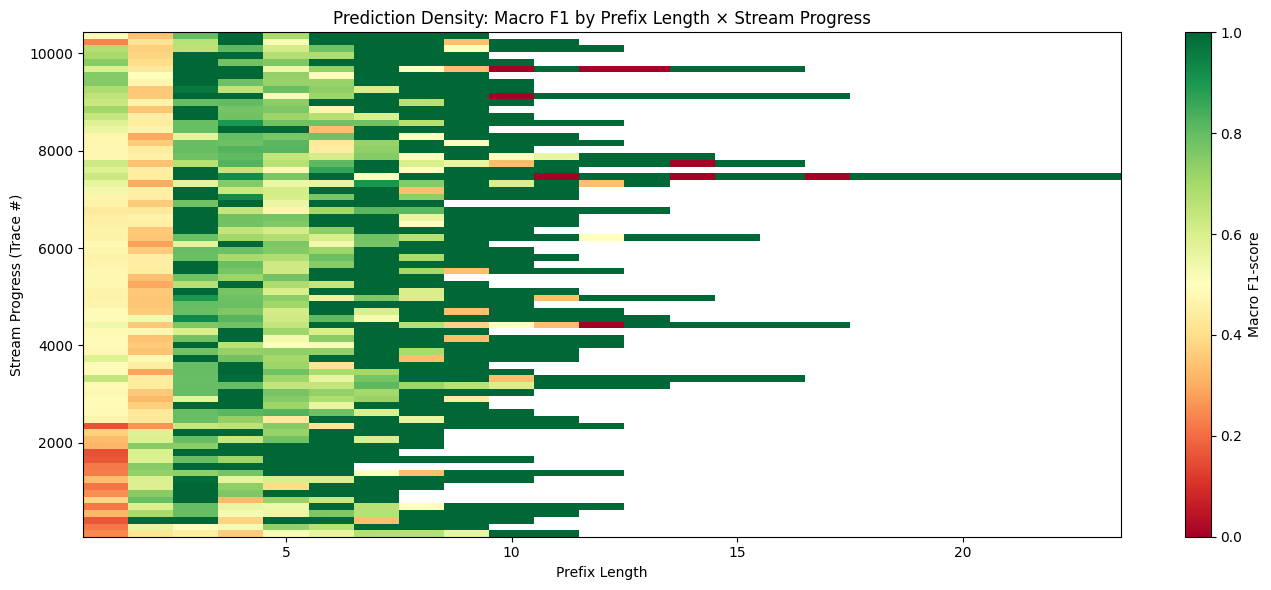

## Comparison table

In [9]:
import pandas as pd
from river import metrics as river_metrics

In [10]:
METRIC_FACTORIES = {
    'macro_f1': river_metrics.MacroF1,
    'accuracy': river_metrics.Accuracy,
}


def recompute_running_metrics(
    predictions_df: pd.DataFrame, start_event_num: int = 0
) -> pd.DataFrame:
    """Recompute running metrics from a given event onwards."""
    metrics_dict = {name: factory() for name, factory in METRIC_FACTORIES.items()}

    predictions_df = (
        predictions_df[predictions_df['event_n'] >= start_event_num]
        .sort_values('event_n')
        .reset_index(drop=True)
        .copy()
    )

    running_values = {name: [] for name in metrics_dict}

    for _, row in predictions_df.iterrows():
        y_true = row['y_true']
        y_pred = row['y_pred']

        if pd.notna(y_true) and pd.notna(y_pred):
            for metric in metrics_dict.values():
                metric.update(y_true, y_pred)

        for metric_name, metric in metrics_dict.items():
            running_values[metric_name].append(f'{metric.get():.3f}')

    for metric_name, values in running_values.items():
        predictions_df[metric_name] = values

    return predictions_df


def first_prediction_event_n(predictions_df: pd.DataFrame) -> float:
    """Return first event_n where model outputs a prediction."""
    pred_mask = pd.notna(predictions_df['y_pred'])

    if 'n_pred' in predictions_df.columns:
        pred_mask &= predictions_df['n_pred'] >= 1

    first_event = predictions_df.loc[pred_mask, 'event_n'].min()
    return first_event

In [11]:
summary_rows = []

for dataset_name, predictions_path_dict in PREDICTIONS_DICT.items():
    # start_event_num = maximum first-prediction event across ALL models in this dataset
    first_pred_events = {}
    for model_name, folder_path in predictions_path_dict.items():
        path = BASE_FOLDER / folder_path / BASE_FILENAME
        df = pd.read_csv(path)
        first_pred_events[model_name] = first_prediction_event_n(df)

    start_event_num = int(max(first_pred_events.values()))

    row = {'dataset_name': dataset_name}

    print(f'Dataset: {dataset_name}, start_event_num: {start_event_num}')

    for model_name, folder_path in predictions_path_dict.items():
        path = BASE_FOLDER / folder_path / BASE_FILENAME
        df = pd.read_csv(path)
        recomputed_df = recompute_running_metrics(df, start_event_num=start_event_num)

        last_row = recomputed_df.iloc[-1]

        for metric in METRIC_FACTORIES.keys():
            row[(metric, model_name)] = last_row[metric]

    summary_rows.append(row)

comparison_table_df = pd.DataFrame(summary_rows).set_index('dataset_name').sort_index()


Dataset: BPIC_13_C, start_event_num: 966
Dataset: BPIC_13_I, start_event_num: 7337
Dataset: BPIC_20_DD, start_event_num: 7335
Dataset: BPIC_20_ID, start_event_num: 8390
Dataset: BPIC_20_PTC, start_event_num: 2130
Dataset: BPIC_20_RFP, start_event_num: 4762
Dataset: BPIC_20_TPD, start_event_num: 10064
Dataset: Helpdesk, start_event_num: 2712


In [12]:
model_order = ['darwin', 'darwin_transformer', 'aht', 'arf', 'srp']
metric_order = ['macro_f1', 'accuracy']

if not comparison_table_df.empty:
    ordered_cols = [
        (metric, model_name)
        for metric in metric_order
        for model_name in model_order
        if (metric, model_name) in comparison_table_df.columns
    ]

    comparison_table_df = comparison_table_df[ordered_cols]
    comparison_table_df.columns = pd.MultiIndex.from_tuples(
        comparison_table_df.columns, names=['metric', 'model']
    )

comparison_table_df

metric       macro_f1                                         accuracy  \
model          darwin darwin_transformer    aht    arf    srp   darwin   
dataset_name                                                             
BPIC_13_C       0.488              0.315  0.402  0.454  0.455    0.540   
BPIC_13_I       0.518              0.351  0.270  0.326  0.318    0.675   
BPIC_20_DD      0.421              0.397  0.443  0.391  0.461    0.877   
BPIC_20_ID      0.441              0.427  0.396  0.417  0.414    0.834   
BPIC_20_PTC     0.420              0.427  0.449  0.494  0.459    0.804   
BPIC_20_RFP     0.391              0.389  0.384  0.370  0.407    0.866   
BPIC_20_TPD     0.358              0.350  0.349  0.262  0.240    0.754   
Helpdesk        0.238              0.219  0.231  0.289  0.279    0.797   

metric                                                
model        darwin_transformer    aht    arf    srp  
dataset_name                                          
BPIC_13_C                 0.474  0.566  0.622  0.613  
BPIC_13_I                 0.632  0.634  0.637  0.640  
BPIC_20_DD                0.883  0.865  0.890  0.886  
BPIC_20_ID                0.840  0.793  0.823  0.814  
BPIC_20_PTC               0.796  0.818  0.847  0.831  
BPIC_20_RFP               0.875  0.870  0.877  0.867  
BPIC_20_TPD               0.735  0.769  0.624  0.606  
Helpdesk                  0.804  0.765  0.822  0.821

## Performance plots

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
from sklearn.metrics import accuracy_score, f1_score

In [14]:
ts_col = 'time:timestamp'
case_col = 'case:concept:name'

In [15]:
def get_bin_metrics(
    dataset_name, model_name, metrics, n_bins=10, case_id_filter=None, display=True
):

    # paths
    predictions_folder = PREDICTIONS_DICT[dataset_name][model_name]
    predictions_path = BASE_FOLDER / predictions_folder / BASE_FILENAME
    dataset_path = DATASET_FOLDER / f'{dataset_name}.xes'

    # read data
    preds_df = (
        pd.read_csv(predictions_path).sort_values('event_n').reset_index(drop=True)
    )
    stream = (
        pm4py.read_xes(str(dataset_path))
        .sort_values(by=[ts_col])
        .reset_index(drop=True)
    )
    stream[ts_col] = pd.to_datetime(stream[ts_col])

    grouped = stream.groupby(case_col, sort=False)
    stream['duration_from_start'] = stream[ts_col] - grouped[ts_col].transform('min')
    stream['trace_duration'] = grouped[ts_col].transform('max') - grouped[
        ts_col
    ].transform('min')
    stream['event_n_in_trace'] = grouped.cumcount() + 1
    stream['trace_n_events'] = grouped[ts_col].transform('size')

    # prepare bins
    time_bins = [[] for _ in range(n_bins)]
    event_bins = [[] for _ in range(n_bins)]

    for pred_row, stream_row in zip(
        preds_df.itertuples(), stream.itertuples(), strict=True
    ):

        case_id = pred_row.trace_id
        y_pred = pred_row.y_pred
        y_true = pred_row.y_true

        if not pd.notna(y_pred) or not pd.notna(y_true):
            continue

        if case_id_filter is not None and case_id != case_id_filter:
            continue

        duration_from_start = stream_row.duration_from_start
        trace_duration = stream_row.trace_duration

        time_frac = (
            (duration_from_start / trace_duration)
            if trace_duration.total_seconds() != 0
            else 0
        )
        time_idx = min(int(time_frac * n_bins), n_bins - 1)

        event_n_in_trace = stream_row.event_n_in_trace
        trace_n_events = stream_row.trace_n_events
        event_idx = min(((event_n_in_trace - 1) * n_bins) // trace_n_events, n_bins - 1)

        # print(f'Processing case ID: {case_id}, ')
        # print(f'Duration from start: {duration_from_start}/{trace_duration}, Time idx: {time_idx}')
        # print(f'Event n in trace: {event_n_in_trace}/{trace_n_events}, Event idx: {event_idx}')
        # print()

        time_bins[time_idx].append((case_id, y_pred, y_true))
        event_bins[event_idx].append((case_id, y_pred, y_true))


    def compute_metrics_for_bins(bins):
        results = {m: [np.nan] * n_bins for m in metrics}
        for i, b in enumerate(bins):
            if not b:
                continue
            _, y_preds, y_trues = zip(*b, strict=True)
            y_preds = list(y_preds)
            y_trues = list(y_trues)
            for m_name, m_func in metrics.items():
                try:
                    results[m_name][i] = float(m_func(y_trues, y_preds))
                except Exception as e:
                    results[m_name][i] = np.nan
                    print(f'Failed to compute {m_name} for bin {i + 1}: {e}')
        return results

    time_metrics = compute_metrics_for_bins(time_bins)
    event_metrics = compute_metrics_for_bins(event_bins)

    # plotting
    if display:
        x = range(1, n_bins + 1)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for m_name, vals in time_metrics.items():
            axes[0].plot(x, vals, marker='o', linewidth=2, label=m_name)
        axes[0].set_xlabel('Time Bin Index')
        axes[0].set_title(f'{dataset_name} — {model_name} — Time Bin')
        axes[0].set_xticks(list(x))
        axes[0].set_xlim(0.5, n_bins + 0.5)
        axes[0].set_ylim(0, 1 + 0.1)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        for m_name, vals in event_metrics.items():
            axes[1].plot(x, vals, marker='o', linewidth=2, label=m_name)
        axes[1].set_xlabel('Event Bin Index')
        axes[1].set_title(f'{dataset_name} — {model_name} — Event Bin')
        axes[1].set_xticks(list(x))
        axes[1].set_xlim(0.5, n_bins + 0.5)
        axes[1].set_ylim(0, 1 + 0.1)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return time_metrics, event_metrics

c:\Users\Pavel\Desktop\PROJECTS\master-thesis\.venv\lib\site-packages\pm4py\utils.py:1000: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn(
c:\Users\Pavel\Desktop\PROJECTS\master-thesis\.venv\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(
c:\Users\Pavel\Desktop\PROJECTS\master-thesis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 7065/7065 [00:02<00:00, 2843.96it/s]


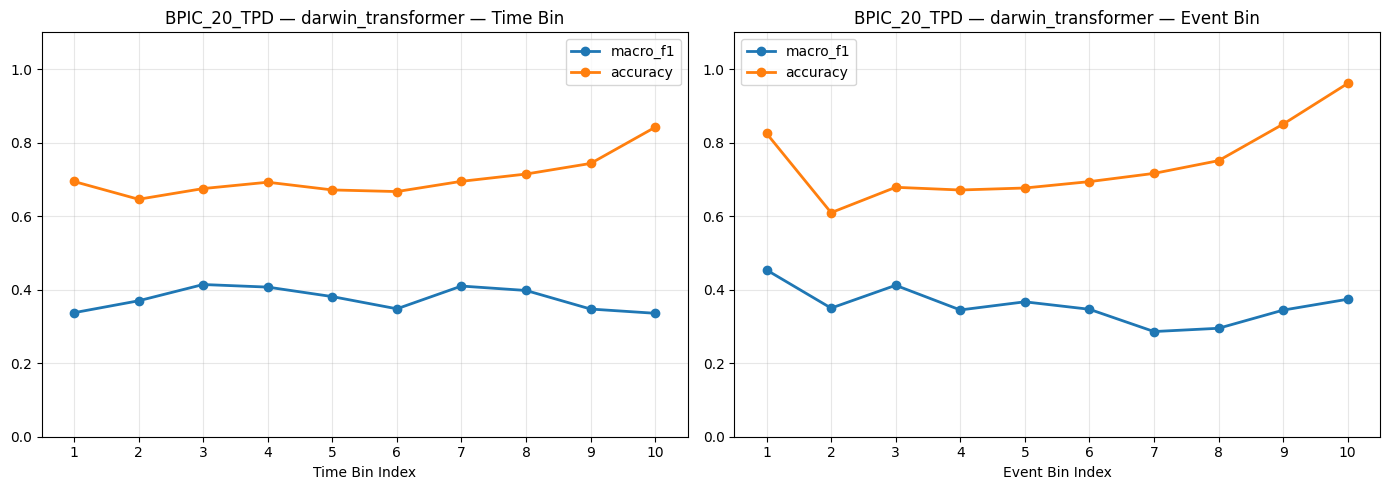

In [16]:
metrics = {
    'macro_f1': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
    'accuracy': accuracy_score,
}

dataset_name = 'BPIC_20_TPD'
model_name = 'darwin_transformer'

time_metrics, event_metrics = get_bin_metrics(
    dataset_name, model_name, n_bins=10, metrics=metrics,
    # case_id_filter='travel permit 65106', # 3 events (2 preds)
    # case_id_filter='travel permit 83467', # 10 events (5 init events, 5 preds)
    # case_id_filter='travel permit 10482', # 10 events (9 preds)
    # case_id_filter='travel permit 13587', # 11 events (10 preds)
    # case_id_filter='travel permit 15078', # 14 events (13 preds)
)

parsing log, completed traces :: 100%|██████████| 4580/4580 [00:01<00:00, 2476.05it/s]


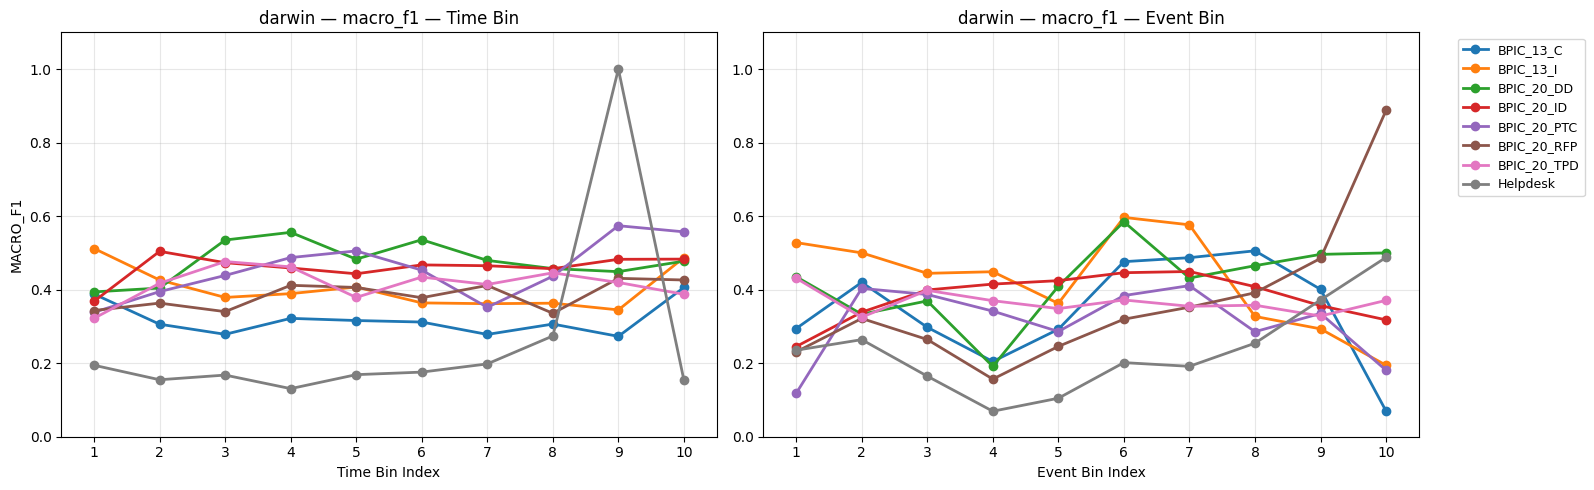

parsing log, completed traces :: 100%|██████████| 4580/4580 [00:02<00:00, 2274.97it/s]


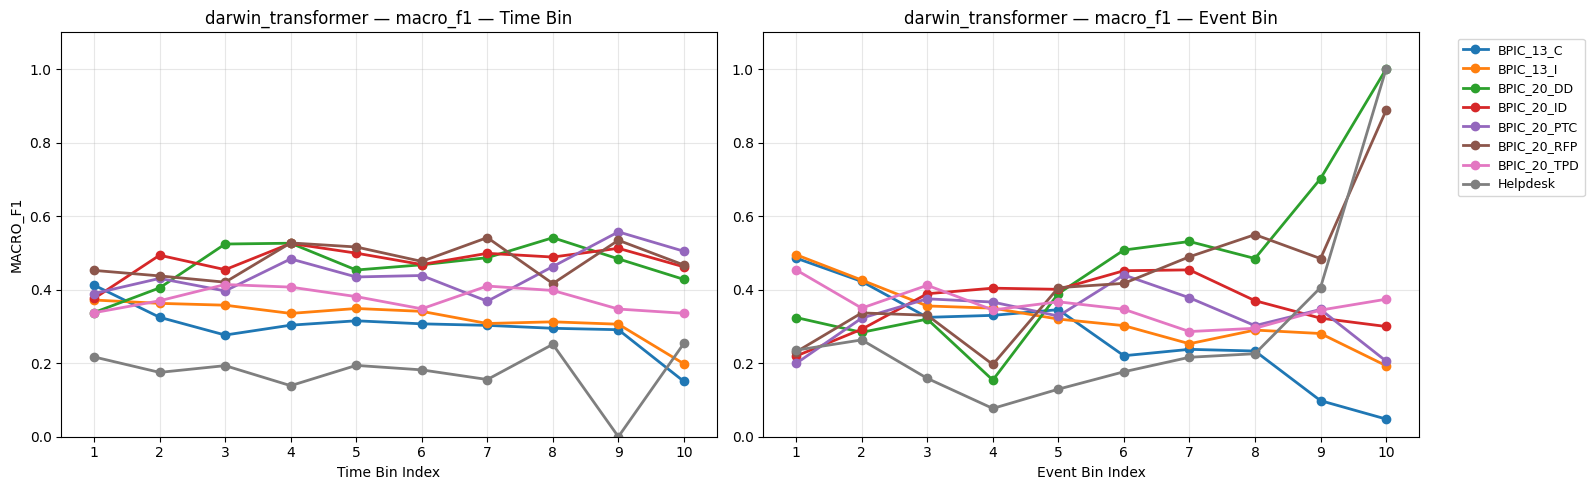

In [18]:
_model_names = [
    'darwin',
    'darwin_transformer',
]

metric = 'macro_f1'
n_bins = 10

for _model_name in _model_names:
    _time_metrics_dict = {}
    _event_metrics_dict = {}

    for _dataset_name in DATASET_LIST:
        _time_metrics, _event_metrics = get_bin_metrics(
            _dataset_name, _model_name, n_bins=n_bins, metrics=metrics, display=False
        )

        _time_metrics_dict[_dataset_name] = _time_metrics[metric]
        _event_metrics_dict[_dataset_name] = _event_metrics[metric]

    # plotting _time_metrics_dict and _event_metrics_dict
    x = range(1, n_bins + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Time metrics plot
    for dataset_name, vals in _time_metrics_dict.items():
        axes[0].plot(x, vals, marker='o', linewidth=2, label=dataset_name)
    axes[0].set_xlabel('Time Bin Index')
    axes[0].set_ylabel(f'{metric.upper()}')
    axes[0].set_title(f'{_model_name} — {metric} — Time Bin')
    axes[0].set_xticks(list(x))
    axes[0].set_xlim(0.5, n_bins + 0.5)
    axes[0].set_ylim(0, 1.1)
    axes[0].grid(True, alpha=0.3)

    # Event metrics plot
    for dataset_name, vals in _event_metrics_dict.items():
        axes[1].plot(x, vals, marker='o', linewidth=2, label=dataset_name)
    axes[1].set_xlabel('Event Bin Index')
    axes[1].set_title(f'{_model_name} — {metric} — Event Bin')
    axes[1].set_xticks(list(x))
    axes[1].set_xlim(0.5, n_bins + 0.5)
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()